# ReAct Agent

## What is ReAct?

**ReAct** (Reasoning + Acting) is an advanced agent paradigm that combines reasoning and action in an interleaved manner. Unlike simple agents that directly respond to queries, ReAct agents:

- **Think** before they act (Reasoning)
- **Use tools** to gather information (Acting)
- **Observe** the results
- **Iterate** until they have enough information to answer

## ReAct Architecture

The ReAct agent follows a cyclical pattern:


```
┌─────────────────────────────────────────┐
│ 1. THOUGHT (Reasoning)                  │
│ "I need to search for information..."   │
└──────────────┬──────────────────────────┘
               │
               ▼
┌─────────────────────────────────────────┐
│ 2. ACTION (Tool Execution)              │
│ Execute: search_tool("query")           │
└──────────────┬──────────────────────────┘
               │
               ▼
┌─────────────────────────────────────────┐
│ 3. OBSERVATION (Result)                 │
│ Receive: tool output/result             │
└──────────────┬──────────────────────────┘
               │
               ▼
        [Sufficient?] ── No ──► Back to THOUGHT
            │
           Yes
            │
            ▼
┌─────────────────────────────────────────┐
│ 4. ANSWER (Final Response)              │
│ Provide final answer to user            │
└─────────────────────────────────────────┘
```


## Key Components

1. **State Management**: Tracks conversation history and agent's thoughts
2. **LLM with Tool Binding**: Language model equipped with available tools
3. **Tools/Functions**: External capabilities (search, calculations, APIs, etc.)
4. **Router Logic**: Decides whether to continue reasoning or finish
5. **Tool Executor**: Runs the selected tools and returns observations

## Advantages

- **Transparent Reasoning**: See the agent's thought process
- **Better Accuracy**: Tools provide factual information
- **Flexible Problem-Solving**: Can handle complex multi-step tasks
- **Reduced Hallucinations**: Grounds responses in real data

In [1]:
from typing import Annotated, Sequence, TypedDict
from dotenv import load_dotenv  
from langchain_core.messages import BaseMessage # The foundational class for all message types in LangGraph
from langchain_core.messages import ToolMessage # Passes data back to LLM after it calls a tool such as the content and the tool_call_id
from langchain_core.messages import SystemMessage # Message for providing instructions to the LLM
from langchain_groq import ChatGroq
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode

In [2]:
load_dotenv()  

True

In [5]:
class AgentState(TypedDict):
    messages : Annotated[Sequence[BaseMessage], add_messages]

In [7]:
@tool
def add(a: int, b: int) -> int:
    """Adds two numbers."""
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """Multiplies two numbers."""
    return a * b

@tool
def subtract(a: int, b: int) -> int:
    """Subtracts two numbers."""
    return a - b

tools = [add, multiply, subtract]

### Define Tools

Tools are functions that the agent can use to perform actions. Each tool:
- Is decorated with `@tool`
- Has a clear docstring (used by LLM to understand when to use it)
- Takes typed parameters
- Returns a specific output

Here we define three mathematical tools: **add**, **multiply**, and **subtract**

In [8]:
import os
Groq_API_Key = os.getenv("GROQ_API_KEY")
llm = ChatGroq(api_key=Groq_API_Key, model="llama-3.1-8b-instant", temperature=0)

In [9]:
llm.bind_tools(tools)

RunnableBinding(bound=ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001AAD18370E0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001AAD1837E00>, model_name='llama-3.1-8b-instant', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'add', 'description': 'Adds two numbers.', 'parameters': {'properties': {'a': {'type': 'integer'}, 'b': {'type': 'integer'}}, 'required': ['a', 'b'], 'type': 'object'}}}, {'type': 'function', 'function': {'name': 'multiply', 'description': 'Multiplies two numbers.', 'parameters': {'properties': {'a': {'type': 'integer'}, 'b': {'type': 'integer'}}, 'required': ['a',

### Bind Tools to LLM

**Tool binding** allows the LLM to:
- Know which tools are available
- Understand when to call them
- Generate proper tool calls with correct parameters

The LLM doesn't execute tools directly—it generates **tool call requests** that we execute separately.

In [10]:
def model_call(state:AgentState) -> AgentState:
    system_prompt = SystemMessage(content=
        "You are my AI assistant, please answer my query to the best of your ability."
    )
    response = llm.invoke([system_prompt] + state["messages"])
    return {"messages": [response]}


### Define the Agent Node

The `model_call` function is the **reasoning node** that:
1. Receives the current state (conversation history)
2. Adds a system prompt with instructions
3. Invokes the LLM to reason about the query
4. Returns the LLM's response (which may include tool calls)

This is where the agent **thinks** and decides what to do next.

In [11]:
def should_continue(state: AgentState): 
    messages = state["messages"]
    last_message = messages[-1]
    if not last_message.tool_calls: 
        return "end"
    else:
        return "continue"

### Define the Router Function

The `should_continue` function is the **decision point** that:
- Checks if the last message contains tool calls
- Returns **"continue"** if tools need to be executed
- Returns **"end"** if the agent has the final answer

This implements the conditional logic in the ReAct loop.

In [12]:
graph = StateGraph(AgentState)
graph.add_node("our_agent", model_call)

tool_node = ToolNode(tools=tools)
graph.add_node("tools", tool_node)

graph.set_entry_point("our_agent")

graph.add_conditional_edges(
    "our_agent",
    should_continue,
    {
        "continue": "tools",
        "end": END,
    },
)

graph.add_edge("tools", "our_agent")

app = graph.compile()

### Build the Graph

Now we construct the ReAct agent graph:

1. **Create StateGraph**: Initialize with our state schema
2. **Add Nodes**:
   - `our_agent`: The reasoning node (calls LLM)
   - `tools`: The action node (executes tools)
3. **Set Entry Point**: Start at the agent node
4. **Add Conditional Edge**: Router that decides "continue" or "end"
5. **Add Loop Edge**: Tools → Agent (for iterative reasoning)
6. **Compile**: Create the executable application

This creates the ReAct loop: Agent → Router → Tools → Agent → ...

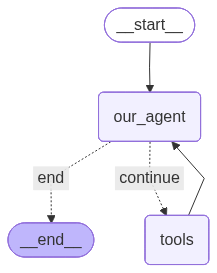

In [13]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

### Create Helper Function

The `print_stream` function pretty-prints the streaming output, showing:
- User messages
- Agent thoughts
- Tool calls
- Tool results
- Final answers

In [ ]:
def print_stream(stream):
    for s in stream:
        message = s["messages"][-1]
        if isinstance(message, tuple):
            print(message)
        else:
            message.pretty_print()

In [14]:
inputs = {"messages": [("user", "Add 40 + 12 and then multiply the result by 6. Also tell me a joke please.")]}
print_stream(app.stream(inputs, stream_mode="values"))

================================ Human Message =================================

Add 40 + 12 and then multiply the result by 6. Also tell me a joke please.
================================== Ai Message ==================================

To solve the problem, I'll follow the order of operations:

1. Add 40 and 12: 
40 + 12 = 52

2. Multiply the result by 6:
52 * 6 = 312

Now, here's a joke for you:

Why couldn't the bicycle stand up by itself?

Because it was two-tired!

I hope you found that one amusing!


In [16]:
inputs = {"messages": [("user", "What is 15 multiplied by 12, then subtract 20 from the result, and finally add 100?")]}
print_stream(app.stream(inputs, stream_mode="values"))

================================ Human Message =================================

What is 15 multiplied by 12, then subtract 20 from the result, and finally add 100?
================================== Ai Message ==================================

To solve the problem, we'll follow the order of operations:

1. Multiply 15 by 12:
15 * 12 = 180

2. Subtract 20 from the result:
180 - 20 = 160

3. Add 100 to the result:
160 + 100 = 260

The final answer is 260.
